# Meta-Black-Box Optimization [![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maxencefaldor/bbobax/blob/main/notebooks/04_meta_bbo.ipynb)

In this notebook, we meta-learn a component of an optimizer over the bbob suite, end to end. The pattern is the point: it is designed to be reused as is, with your component in place of ours.

Any meta-BBO objective must turn performance on many functions into one number, and any way of doing that is a weighting -- averaging raw fitness would let `bent_cigar`'s $10^8$ range outvote `katsuura`'s $10$ a million times over. The pattern here makes every such choice explicit and cheap to revisit:

- **Stratify, don't sample.** The suite is enumerable, so every meta-step sees every function at every dimension. Sampling tasks would add variance and buy nothing.
- **Common random numbers.** Every candidate in the meta-population sees the *same* instances. Comparisons are paired, which is the single largest variance reduction available.
- **Standardize within a task, across candidates.** Each task scores a candidate relative to the other candidates on that same task, in standard deviations. Scales never cross task boundaries.
- **Median across tasks.** Each task gets one equal vote, robustly. The weighting is a visible line of code, and the per-task scores are kept, so any other reading is a post-hoc computation rather than a re-run.
- **Train relative, evaluate absolute.** The standardized objective can only say "better than its siblings". Whether the result is *good* is answered after training, with COCO's own instrument: the ECDF over target precisions, per function.

## Install

You will need Python 3.11 or later, and a working JAX installation. For example, you can install JAX with:

In [ ]:
%pip install -U "jax[cuda]"

Then, install bbobax from PyPi:

In [ ]:
%pip install -U "bbobax[notebooks]"

## Import

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from evosax.algorithms import CMA_ES

import bbobax

## What we meta-learn

Three scalars of CMA-ES: log-multipliers on `std_init` (the initial step size), `c_mean` (the mean learning rate), and `d_std` (the step-size damping). Two properties make them a good subject:

- $\theta = 0$ **is CMA-ES's published defaults**, exactly. The meta-optimization starts from decades of tuning, and the learned result reads directly as "how far from the defaults, and in which direction".
- **They are dimension-independent**, so one $\theta$ serves every task -- which is what lets the training loop stratify over dimensions.

The harness does not care what $\theta$ is. To meta-learn something else -- an update rule, a schedule, a network -- change `make_run` and keep everything downstream.

In [2]:
def es_params_from(es, theta):
    """Map theta to inner-CMA-ES parameters; theta = 0 is the defaults."""
    base = es.default_params
    return base.replace(
        std_init=base.std_init * jnp.exp(theta[0]),
        c_mean=base.c_mean * jnp.exp(theta[1]),
        d_std=base.d_std * jnp.exp(theta[2]),
    )

## Tasks

A task is one function at one dimension. Training uses all 24 functions at $D \in \{2, 3, 5\}$ -- 72 tasks, each compiled once and reused every meta-step. Dimension 10 is deliberately held out for evaluation: $\theta$ is dimension-independent, so generalizing across dimension is a claim we can actually test.

In [3]:
train_dims = (2, 3, 5)
eval_dim = 10  # held out from training

population_size = 16
num_generations = 64
num_instances = 2  # instances per task per meta-step; paired across candidates

train_problems = {
    (name, num_dims): problem
    for num_dims in train_dims
    for name, problem in bbobax.bbob_suite(num_dims=num_dims).items()
}
len(train_problems)

72

## Inner loop

One run of CMA-ES on one problem instance, returning the best-so-far *precision* $f_\mathrm{best} - f_\mathrm{opt}$ after every generation -- the whole trajectory, because training reads its endpoint and evaluation reads all of it.

The run is vmapped twice: over the shared instance keys (inner), and over the meta-population's candidates (outer). Everything a candidate experiences is determined by `key` and $\theta$, so identical keys across candidates is all it takes for comparisons to be paired.

In [4]:
def make_run(problem):
    """Build the compiled (instances x candidates) runner for one task."""
    es = CMA_ES(population_size=population_size, solution=jnp.zeros(problem.num_dims))

    def run(key, theta):
        es_params = es_params_from(es, theta)
        key_instance, key_mean, key_init, key_run = jax.random.split(key, 4)
        params = problem.sample(key_instance)
        state = es.init(key_init, problem.sample_x(key_mean), es_params)

        def step(state, key):
            key_ask, key_eval, key_tell = jax.random.split(key, 3)
            population, state = es.ask(key_ask, state, es_params)
            keys = jax.random.split(key_eval, population_size)
            fitness = jax.vmap(problem.evaluate, in_axes=(0, 0, None))(
                keys, population, params
            ).fitness
            state, _ = es.tell(key_tell, population, fitness, state, es_params)
            return state, jnp.min(fitness)

        _, best = jax.lax.scan(step, state, jax.random.split(key_run, num_generations))
        return jax.lax.cummin(best) - params.f_opt

    return jax.jit(jax.vmap(jax.vmap(run, in_axes=(0, None)), in_axes=(None, 0)))


train_runs = {task: make_run(problem) for task, problem in train_problems.items()}

## The meta-objective

Per task: the final log-precision, clipped at $10^{-8}$ -- COCO's hardest target, below which BBOB itself considers a problem solved -- and averaged over the paired instances. Then the two explicit choices: standardize each task's column across candidates, and take the median across tasks.

Log-precision, not precision: the inner score should live on the scale the problem is actually judged on, and a single Cauchy-tailed value would otherwise own the task's standard deviation.

In [5]:
def scores(task_keys, thetas):
    """Per-task mean log-precision, shape (candidates, tasks). The stored record."""
    per_task = []
    for run in train_runs.values():
        precision = run(task_keys, thetas)  # (candidates, instances, generations)
        log_precision = jnp.log10(jnp.clip(precision[..., -1], min=1e-8))
        per_task.append(jnp.mean(log_precision, axis=-1))
    return jnp.stack(per_task, axis=-1)


def meta_objective(score_matrix):
    """Standardize within each task across candidates, then median across tasks."""
    return jnp.median(jax.nn.standardize(score_matrix, axis=0), axis=-1)

## Meta-train

CMA-ES over $\theta$ as well -- at 3 parameters, the full covariance costs nothing and there is no reason to use anything weaker.

One subtlety is worth knowing before reading any training curve: the standardized objective is *relative by construction*. Its mean over candidates is 0 at every meta-generation, whether the run is succeeding or failing. So the objective trains, and a separate absolute probe monitors: the median log-precision of the current mean $\theta$, on the same paired instances. That number is comparable across meta-generations; the z-values are not.

In [6]:
meta_population_size = 16
num_meta_generations = 30

meta_es = CMA_ES(population_size=meta_population_size, solution=jnp.zeros(3))
meta_es_params = meta_es.default_params.replace(std_init=0.5)

key = jax.random.key(0)
key, subkey = jax.random.split(key)
meta_state = meta_es.init(subkey, jnp.zeros(3), meta_es_params)

monitor = []
for meta_generation in range(num_meta_generations):
    key, key_ask, key_task, key_tell = jax.random.split(key, 4)
    # Fresh instances every meta-step, but the *same* instances for every
    # candidate and for the monitor: paired, not shared-nothing.
    task_keys = jax.random.split(key_task, num_instances)

    thetas, meta_state = meta_es.ask(key_ask, meta_state, meta_es_params)
    meta_fitness = meta_objective(scores(task_keys, thetas))
    meta_state, _ = meta_es.tell(
        key_tell, thetas, meta_fitness, meta_state, meta_es_params
    )

    absolute = jnp.median(scores(task_keys, meta_state.mean[None]))
    monitor.append(float(absolute))
    if (meta_generation + 1) % 10 == 0:
        print(
            f"meta-generation {meta_generation + 1:3d}  "
            f"median log10-precision at mean theta: {absolute:+.3f}"
        )

theta = meta_state.mean
theta

meta-generation  10  median log10-precision at mean theta: -3.400


meta-generation  20  median log10-precision at mean theta: -2.669


meta-generation  30  median log10-precision at mean theta: -3.505


Array([ 0.29636908,  0.3184765 , -0.4734901 ], dtype=float32)

The learned $\theta$ reads directly against the defaults: each entry is $\log$ of a multiplier, so e.g. $\theta_0 = -0.7$ means "start with half the default step size".

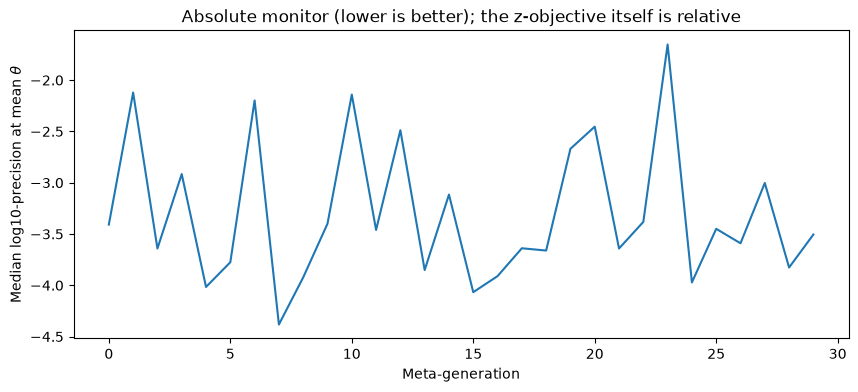

std_init: x1.345 of default
  c_mean: x1.375 of default
   d_std: x0.623 of default


In [7]:
plt.figure(figsize=(10, 4))
plt.plot(monitor)
plt.xlabel("Meta-generation")
plt.ylabel("Median log10-precision at mean $\\theta$")
plt.title("Absolute monitor (lower is better); the z-objective itself is relative")
plt.show()

for name, value in zip(("std_init", "c_mean", "d_std"), theta):
    print(f"{name:>8}: x{float(jnp.exp(value)):.3f} of default")

## Evaluate

Training only ever certified "better than its siblings". The exam is absolute, on the held-out dimension, with COCO's instrument: the **ECDF over target precisions**. The targets are the 51 values $10^2, 10^{1.8}, \ldots, 10^{-8}$ -- `cocopp`'s `pprldmany_target_values`, the grid behind every published BBOB runtime-distribution plot. A point on the curve reads: after this many evaluations, this fraction of (function, instance, target) triples has been solved.

This is where per-function storage pays: the same trajectories give the aggregate curve, the per-function diagnosis, and any re-weighted reading, with no further runs.

CMA-ES defaults: 0.178 of triples solved at full budget
   meta-learned: 0.204 of triples solved at full budget


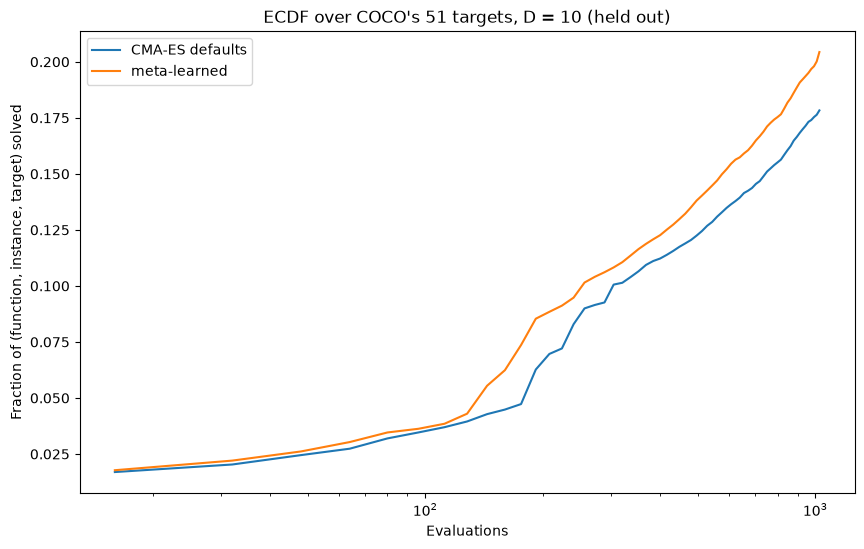

In [8]:
targets = 10.0 ** np.arange(2, -8.2, -0.2)  # cocopp's pprldmany_target_values
num_eval_instances = 8

eval_problems = bbobax.bbob_suite(num_dims=eval_dim)
eval_runs = {name: make_run(problem) for name, problem in eval_problems.items()}

key, key_eval = jax.random.split(key)
eval_keys = jax.random.split(key_eval, num_eval_instances)
candidates = jnp.stack([jnp.zeros(3), theta])  # default CMA-ES vs learned

# (function, candidate, instance, generation) best-so-far precisions.
trajectories = np.stack(
    [np.asarray(run(eval_keys, candidates)) for run in eval_runs.values()]
)

# solved[..., generation, target]: has this trajectory reached this target yet?
solved = trajectories[..., None] <= targets
evaluations = (np.arange(num_generations) + 1) * population_size

plt.figure(figsize=(10, 6))
for candidate, label in enumerate(("CMA-ES defaults", "meta-learned")):
    fraction = solved[:, candidate].mean(axis=(0, 1, 3))
    plt.plot(evaluations, fraction, label=label)
    print(f"{label:>15}: {fraction[-1]:.3f} of triples solved at full budget")
plt.xscale("log")
plt.xlabel("Evaluations")
plt.ylabel("Fraction of (function, instance, target) solved")
plt.title(f"ECDF over COCO's 51 targets, D = {eval_dim} (held out)")
plt.legend()
plt.show()

And the per-function reading -- where the aggregate came from, and where the learned $\theta$ wins or loses:

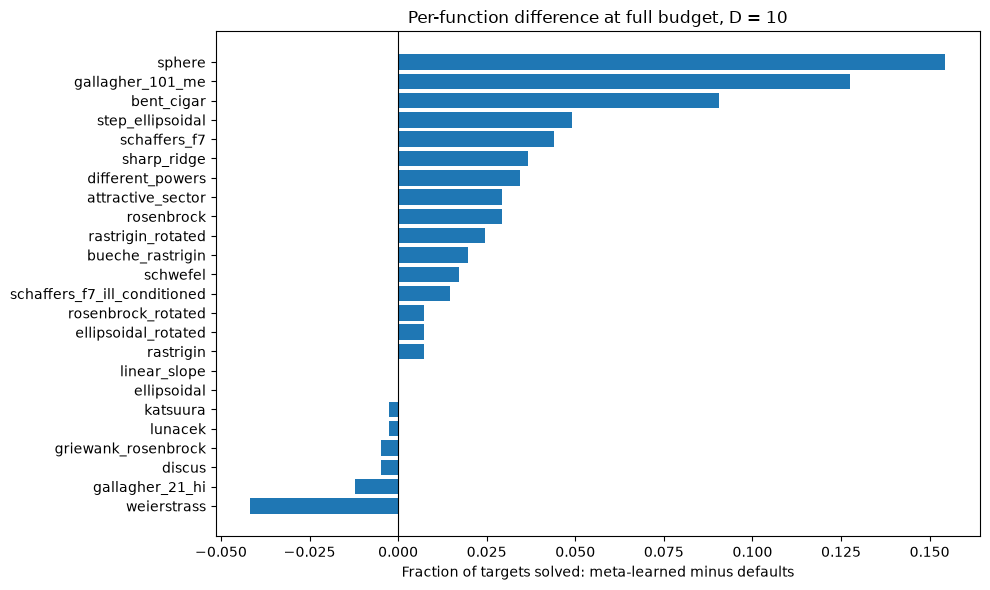

In [9]:
final = solved[..., -1, :].mean(axis=(2, 3))  # fraction solved at full budget
delta = final[:, 1] - final[:, 0]
order = np.argsort(delta)

plt.figure(figsize=(10, 6))
plt.barh(np.array(list(eval_runs))[order], delta[order])
plt.axvline(0.0, color="black", linewidth=0.8)
plt.xlabel("Fraction of targets solved: meta-learned minus defaults")
plt.title(f"Per-function difference at full budget, D = {eval_dim}")
plt.tight_layout()
plt.show()

## Reusing the pattern

To meta-learn your own component, replace `es_params_from` and `make_run`; the objective, the training loop and the evaluation do not change. Three honest reminders as you do:

- The aggregation is still a choice -- equal-variance votes and a median are *defensible*, not neutral. They are two visible lines in `meta_objective`, and the per-task `scores` matrix is the record: re-weight it at read time rather than baking a weighting into a re-run.
- Train and test must not share everything. Here dimension 10 is held out; held-out *functions* (train on four of BBOB's five groups, test on the fifth) is the stronger claim, and `bbobax.ManyAffine` provides a space of unseen blends between the 24.
- The z-objective needs every candidate on the same instances -- if you parallelize the meta-population, keep the instance keys shared, or the pairing (and most of the variance reduction) silently disappears.

## Next

- [05_qd](05_qd.ipynb) -- optimizing for quality *and* diversity on the same problems.